In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as c

In [2]:
# load the data
fp = '/data2/hoppener/radio-astronomy-by-notebooks/working_class_3/'
file = 'test_data'
fft_file = 'FFT_data'
file_auto = 'data_fft_autocorr_int'

# load as np.array
data = np.fromfile(fp + file, dtype = np.complex64) #contains complex numbers
fft_data = np.fromfile(fp + fft_file, dtype=np.complex64)
data_auto = np.fromfile(fp + file_auto, dtype=np.float32) # read out as float32 otherwise numbers blow up

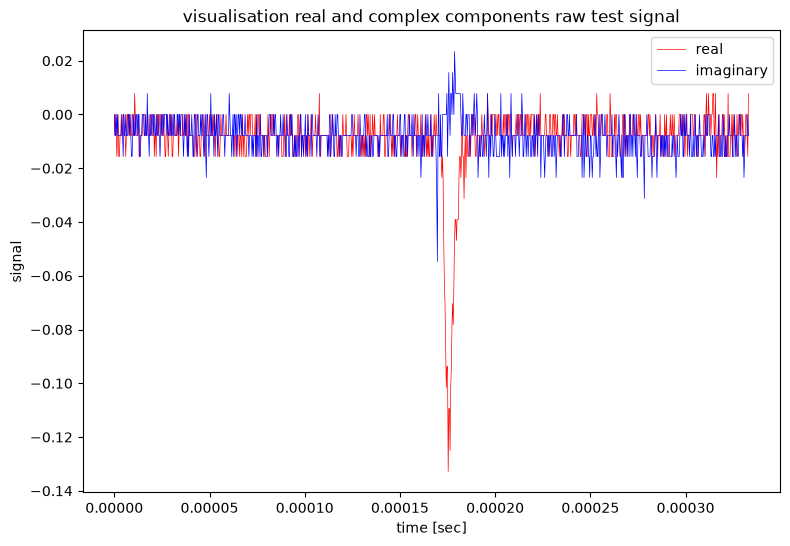

In [3]:
# take the real and complex components of the data
real = np.real(data)
compl = np.imag(data)

# define GNU radio setup constants
samp_rate = 3e6
center_frequency = 1.42e9
dt = 1/samp_rate
time = np.arange(0, len(data)*dt-dt, dt) # corresponding measuring time for data

# visualise raw test signal
plt.figure(figsize=(9,6))
plt.title('visualisation real and complex components raw test signal')
plt.plot(time[0:1000], real[0:1000], color='red', linewidth=0.5, label = 'real')
plt.plot(time[0:1000], compl[0:1000], color='blue', linewidth=0.5, label = 'imaginary')
plt.xlabel('time [sec]')
plt.ylabel('signal')
plt.legend()
plt.show()

The data rate is 24.0 mega bytes per second


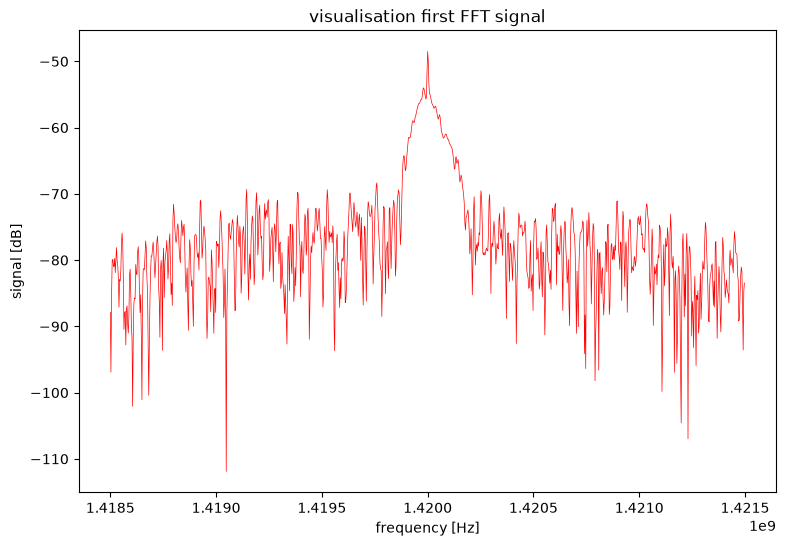

In [4]:
# reshape the FFT data 
fft_size = 1024
N_fft = fft_data.size // 1024
fft_data = fft_data.reshape(N_fft, fft_size)
fft_power = np.abs(fft_data)**2
fft_dB = 10*np.log10(fft_power)

# calculate data rate 
data_rate = 80748544 / (fft_data.size*dt) #bytes per second (bytes from file size)
print("The data rate is", data_rate/10**6, "mega bytes per second")

# calculate the corresponding frequency
freq_fft = np.fft.fftfreq(fft_size, d=dt)
freq_fft = np.fft.fftshift(freq_fft) + center_frequency # center around 1.42Ghz

# visualise FFT signal (why is it negative?)
plt.figure(figsize=(9,6))
plt.title('visualisation first FFT signal')
plt.plot(freq_fft, fft_dB[0], color='red', linewidth = 0.5)
plt.xlabel('frequency [Hz]')
plt.ylabel('signal [dB]')
plt.show()

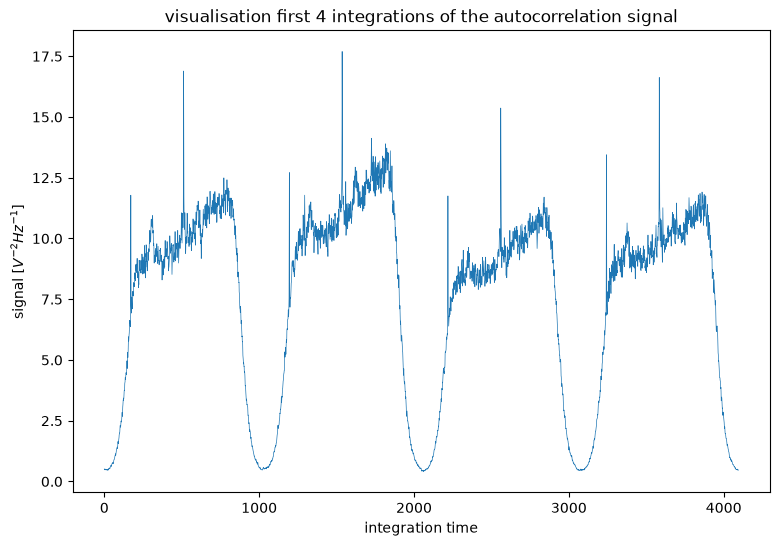

In [5]:
# visualise autocorrelation signal
plt.figure(figsize=(9,6))
plt.title('visualisation first 4 integrations of the autocorrelation signal')
plt.plot(data_auto[0:4*1024], linewidth = 0.5)
plt.xlabel("integration time")
plt.ylabel("signal [$V^{-2}Hz^{-1}$]")
plt.show()

In [6]:
# reshape the autocorrelation data, starting each new integration on a new line
vector_length = 1024
N_spectra = data_auto.size // vector_length # number of integrated spectra
data_auto_spectra = data_auto.reshape(N_spectra, vector_length) 

# calculate the autocorrelator frequency
frequency = np.fft.fftfreq(vector_length, d=dt)
frequency = np.fft.fftshift(frequency) + center_frequency # center around 1.42Ghz

[]

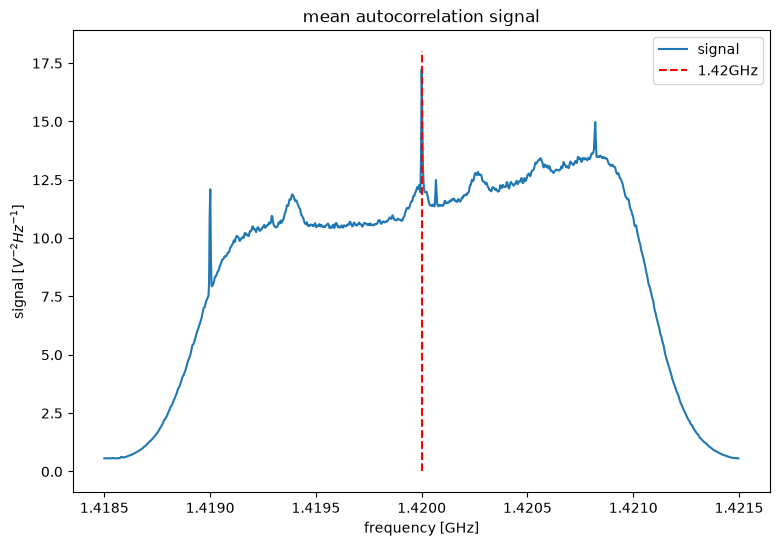

In [7]:
# visualise the mean autocorrelated signal
plt.figure(figsize=(9,6))
plt.title('mean autocorrelation signal')
plt.plot(frequency/1e9, np.mean(data_auto_spectra, axis=0), label = 'signal')
plt.vlines(1.42, 0, 18, linestyle = 'dashed', color = 'red', label = '1.42GHz')
plt.xlabel("frequency [GHz]")
plt.ylabel("signal [$V^{-2}Hz^{-1}$]")
plt.legend()
plt.plot()

In [ ]:
# Y-factor calibration (formula's from ERA book)
hot_load = ... # power with the microwave absorber
cold_load = ... # power on reference part of the sky 
P_on = ... # power on source
P_off = cold_load 
T_hot = 295 # temperature of the microwave absorber
T_cold = 10 # system temperature = T_cmb + T_clouds
Y = hot_load/cold_load
noise_temp = (T_hot-Y*T_cold)/(Y-1)
P_mu = noise_temp*c.k_B # noise power

# conversion from voltage to temperature (source: https://www.aoc.nrao.edu/evla/geninfo/memoseries/evlamemo90.pdf)
G = (hot_load - cold_load) / (T_hot - T_cold) 
T_source = (P_on - P_off) / G 

In [ ]:
# plot the brightness temperature of the source against frequency
plt.figure(figsize=(9,6))
plt.title('Brightness temp plot')
plt.plot(frequency/1e9, T_source)
plt.xlabel("frequency [GHz]")
plt.ylabel("$T_b$ [K]") 
plt.plot()